# TP2 : Reconocimiento de Actividades Humanas con Machine Learning

## Contexto general

En este trabajo práctico vamos a abordar un problema clásico de **clasificación supervisada**: predecir la actividad que está realizando una persona a partir de mediciones obtenidas por sensores de un smartphone ([documentación del dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)).

Este tipo de problema aparece en muchas aplicaciones reales de ingeniería y ciencia de datos, por ejemplo:

- monitoreo de actividad física,
- salud digital,
- sistemas de asistencia,
- interfaces inteligentes,
- dispositivos *wearables* y móviles.

La idea central es construir un flujo de trabajo completo de *machine learning*, desde la exploración de los datos hasta la evaluación de distintos modelos de clasificación.

## Objetivos del TP

A lo largo de este notebook se espera que puedan:

- comprender la estructura general del problema,
- explorar y analizar el conjunto de datos,
- preparar las variables para el modelado,
- aplicar técnicas de reducción de dimensionalidad (PCA),
- entrenar distintos clasificadores (regresion logistica, arbol de decision y random forrest),
- comparar resultados y discutir ventajas y limitaciones de cada enfoque.

## Consigna general

No se busca solamente ejecutar código, sino también **interpretar** qué se está haciendo en cada etapa y **justificar** las decisiones tomadas.

En particular, al finalizar el TP deberían poder responder preguntas como:

- ¿qué tipo de problema de aprendizaje automático estamos resolviendo?
- ¿qué información contienen las variables de entrada?
- ¿por qué ciertas transformaciones son útiles para algunos modelos y no para otros?
- ¿cómo comparar modelos más allá de una única métrica?


### **Consignas presentacion:** La presentación debe tener un máximo de 4 diapositivas y una duración aproximada de **5 minutos**. La estructura de las diapositivas debe ser la siguiente:
  1. Presentación del grupo y del problema a resolver.
  2. Datos, pre-procesamiento y PCA.
  3. Modelado.
  4. Resultados/Conclusiones.

Durante la presentación deberán explicar claramente las siguientes etapas del trabajo:
- Análisis exploratorio de datos (EDA):
Qué observaron en los datos: estructura del dataset, variables importantes, valores faltantes, distribuciones, posibles outliers y relaciones entre variables.

- PCA : Nuevas variables, varianza acumulada y cantidad de variables.

- Modelos regresion logistica, Árbol de Decisión y Random Forrest:
Qué modelos probaron, por qué los eligieron y cómo ajustaron sus parámetros o configuraciones para mejorar el rendimiento.

- Evaluación y testeo del modelo:
Cómo evaluaron el modelo, qué métricas utilizaron y qué resultados obtuvieron en el conjunto de test.

El objetivo de esta presentación es mostrar que realmente comprendieron el proceso que realizaron y que pueden explicarlo de manera clara.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [3]:
# Cargar datasets de train y test
df_train = pd.read_csv('https://raw.githubusercontent.com/juanserrano90/SIA_itba/refs/heads/main/TP2/train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/juanserrano90/SIA_itba/refs/heads/main/TP2/test.csv')

### Descripción del conjunto de datos

El dataset utilizado corresponde a un problema de **reconocimiento de actividad humana**. Cada observación representa una ventana de señales registradas por sensores inerciales de un teléfono móvil, y la variable objetivo indica la actividad realizada por la persona.

En el conjunto de datos aparecen dos tipos de información importantes:

- una columna con la **actividad** a predecir,
- una columna que identifica al **sujeto**,
- un conjunto grande de variables numéricas derivadas de las señales medidas por los sensores.

### Observación importante

En este TP el objetivo principal es predecir la variable **`Activity`**.  
La columna **`subject`** no describe directamente el movimiento, sino la identidad del participante. *Por eso conviene pensar críticamente si debe utilizarse o no como predictor.*

## Hoja de ruta del análisis

El trabajo seguirá, de manera general, los siguientes pasos:

1. inspección inicial de los datos,
2. análisis exploratorio,
3. preparación de variables,
4. reducción de dimensionalidad,
5. entrenamiento de modelos,
6. evaluación y comparación de resultados.

In [4]:
df_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


___

# 1. Análisis Exploratorio de Datos (EDA)
### Preguntas orientadoras

Mientras ejecutan las celdas, intenten responder:

a) ¿Cuántas observaciones y cuántas variables hay? \
b) ¿Todas las variables predictoras son numéricas?\
c) ¿Hay datos faltantes?\
d) ¿Las clases parecen estar balanceadas o desbalanceadas?\
e) ¿Qué implicancias podría tener esto para el entrenamiento?\
f) ¿Cuántos sujetos únicos hay?

El análisis exploratorio no solo sirve para “mirar” los datos: también ayuda a anticipar posibles decisiones de preprocesamiento y modelado.

___

In [5]:
df_train.shape

(7352, 563)

a) Hay `7352 observaciones` y `563 variables`

___

In [6]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 31.6 MB


b) Sí, las `561 variables predictoras son numéricas`, de tipo `float64`. La columna Activity es la variable objetivo.

___

In [7]:
df_train.isna().sum().sort_values(ascending=False)

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

c) No hay variables con datos faltantes

___

In [8]:
df_train["Activity"].value_counts(normalize=True).mul(100).round(2)

Activity
LAYING                19.14
STANDING              18.69
SITTING               17.49
WALKING               16.68
WALKING_UPSTAIRS      14.59
WALKING_DOWNSTAIRS    13.41
Name: proportion, dtype: float64

d) Las seis clases presentan proporciones entre el 13,41 % y el 19,14 %, cercanas al 16,67 % que correspondería a una distribución uniforme. Por lo tanto, existe un desbalance leve, sin un predominio marcado de ninguna clase.

___

e) 
* Favorecer ligeramente la prediccion de clases mas frecuentes como `LAYING`
* Perjudicar a las clases menos representadas como `WALKING_DOWNSTAIRS`

___

In [9]:
df_train["subject"].nunique()

21

f) Hay `21 sujetos` unicos

___

Se aplicó K-Means para explorar si los agrupamientos obtenidos se correspondían con las seis actividades reales.

Los clusters no presentan una correspondencia exacta con las seis actividades. Sin embargo, se observa una separación clara entre dos grandes grupos:

- Los clusters 0, 3 y 5 agrupan actividades estáticas: `LAYING`, `SITTING` y `STANDING`.
- Los clusters 1, 2 y 4 agrupan actividades dinámicas: `WALKING`, `WALKING_DOWNSTAIRS` y `WALKING_UPSTAIRS`.

Dentro de estos grupos existe una mezcla de actividades, aunque algunos clusters muestran un predominio particular: el 93 % del cluster 3 corresponde a `LAYING` y el 70 % del cluster 2 a `WALKING_DOWNSTAIRS`.

En esta ejecución, K-Means identifica principalmente la diferencia entre actividades estáticas y dinámicas, pero no separa de forma consistente las seis actividades individuales.

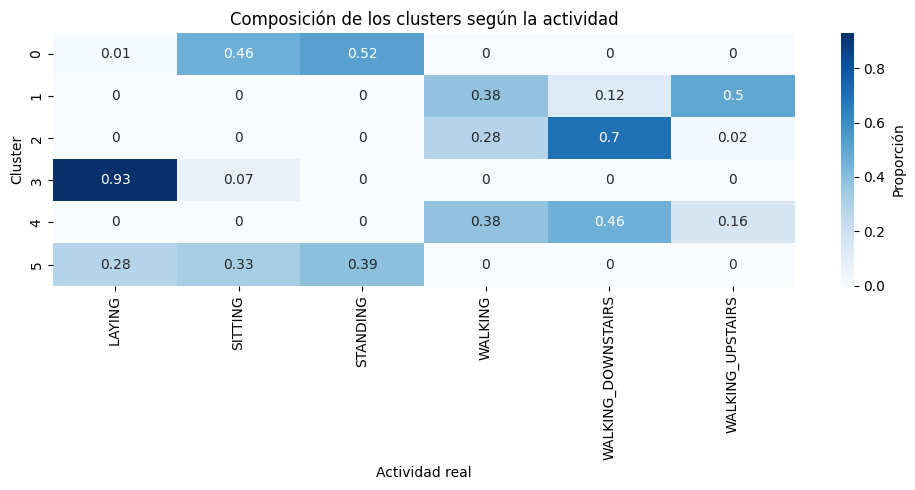

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_cluster = df_train.drop(columns=["Activity", "subject"])
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
tabla_clusters = pd.crosstab(clusters, df_train["Activity"], normalize="index").round(2)

plt.figure(figsize=(10, 5))
sns.heatmap(
    tabla_clusters,
    annot=True,
    cmap="Blues",
    cbar_kws={"label": "Proporción"})

plt.title("Composición de los clusters según la actividad")
plt.xlabel("Actividad real")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

___

# 2. Preparación de los datos

### Guía orientadora:
* Codificar la variable objetivo 'Activity' en el conjunto de entrenamiento y testeo.
* Verificar la codificación de 'Activity' en las primeras 5 instancias de entrenamiento, así como que se hayan codificado correctamente todas las actividades presentes en el dataset.
* Escalar las variables numéricas.
* ¿Qué variables del dataset eligen como predictoras para su modelo y por qué?

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_train["Activity"] = encoder.fit_transform(df_train["Activity"])
df_test["Activity"] = encoder.transform(df_test["Activity"])
df_train["Activity"].head(5)

0    2
1    2
2    2
3    2
4    2
Name: Activity, dtype: int64

In [12]:
df_train["Activity"].unique()

array([2, 1, 0, 3, 4, 5])

In [13]:
df_test["Activity"].unique()

array([2, 1, 0, 3, 4, 5])

In [14]:
X_train = df_train.drop(columns=["Activity", "subject"])
X_test = df_test[X_train.columns]
y_train = df_train["Activity"]
y_test = df_test["Activity"]

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Utilizamos todas las variables predictoras a excepción de subject porque queremos realizar la predicción a partir de una persona nueva

___

# 3. Reducción de dimensionalidad con PCA

El dataset contiene un número elevado de variables. Cuando trabajamos con muchas dimensiones, pueden aparecer varios desafíos: mayor costo computacional, redundancia entre variables, dificultad para interpretar los datos, o riesgo de sobreajuste en algunos modelos.

Para abordar este problema se utilizará **PCA (Análisis de Componentes Principales)**, una técnica que transforma las variables originales en un nuevo conjunto de componentes linealmente independientes que capturan gran parte de la variabilidad del sistema.

Aplicar PCA para reducir la dimensionalidad del dataset antes de entrenar.

### Guía orientadora

- ¿Cuánta varianza explican las primeras componentes?
- ¿Cómo se ve la varianza acumulada en función del número de componentes?
- ¿Cuántas componentes van a conservar?
- ¿Qué se gana y qué se pierde al reducir dimensionalidad?

In [16]:
pca = PCA(svd_solver="full")
pca.fit(X_train_scaled)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

tabla_varianza = pd.DataFrame({
    "Componente": np.arange(1, len(varianza_acumulada) + 1),
    "Varianza explicada (%)": pca.explained_variance_ratio_ * 100,
    "Varianza acumulada (%)": varianza_acumulada * 100})

display(tabla_varianza.head(10).round(2))

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,1,50.78,50.78
1,2,6.58,57.36
2,3,2.81,60.17
3,4,2.50,62.67
4,5,1.89,64.56
5,6,1.72,66.28
6,7,1.37,67.66
7,8,1.20,68.85
8,9,1.00,69.85
9,10,0.97,70.82


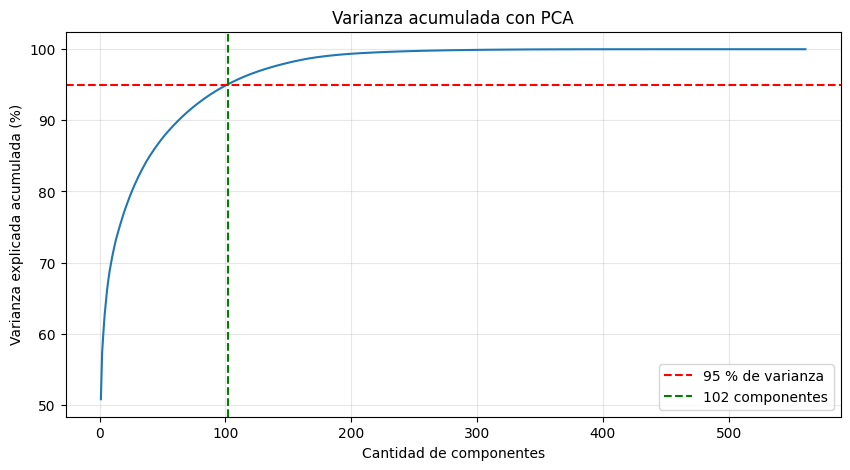

Para conservar al menos el 95 % se necesitan 102 componentes.


In [17]:
n_componentes = np.searchsorted(varianza_acumulada, 0.95) + 1

plt.figure(figsize=(10, 5))
plt.plot(tabla_varianza["Componente"], varianza_acumulada * 100)
plt.axhline(95, color="red", linestyle="--", label="95 % de varianza")
plt.axvline(n_componentes, color="green", linestyle="--", label=f"{n_componentes} componentes")
plt.xlabel("Cantidad de componentes")
plt.ylabel("Varianza explicada acumulada (%)")
plt.title("Varianza acumulada con PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Para conservar al menos el 95 % se necesitan {n_componentes} componentes.")

Teniendo en cuenta el resultado, se conservarán 102 componentes dado que explican la varianza deseada del 95%

Al reducir la dimensionalidad con PCA se obtiene una representación más compacta de los datos. Esto permite reducir redundancia entre variables, disminuir el costo computacional y el riesgo de overfitting. Por el otro lado, la reducción de dimensionalidad hace que se pierda parte de la información y que la interpretación resulte más compleja.

In [18]:
X_train_pca = pca.transform(X_train_scaled)[:, :n_componentes]
X_test_pca = pca.transform(X_test_scaled)[:, :n_componentes]

___

# 4.1 Modelo 1: Regresión Logística

Como primer modelo de referencia se utilizará una **Regresión Logística** para clasificación multiclase.

Aunque se trata de un modelo relativamente simple, suele ser una muy buena línea de base por varias razones:

- es rápido de entrenar,
- funciona bien en muchos problemas de clasificación,
- permite evaluar el impacto del preprocesamiento realizado,
- ofrece un punto de comparación frente a modelos más complejos.

En este caso se entrena sobre la representación reducida obtenida con **PCA**, lo cual ayuda a simplificar el espacio de entrada.

### Ajuste de hiperparámetros

No se utilizará una única configuración fija del modelo. En su lugar, se explorarán distintas combinaciones de hiperparámetros para encontrar una alternativa con mejor desempeño.

### Guía Orientadora
- Crear un modelo de Regresión Logística.
- Hacer un ajuste fino de hiperparámetros.
- Entrenar un modelo optimizado.

### Preguntas para pensar

- ¿Cómo influye la regularización en el modelo?
- ¿Qué ventaja puede tener usar PCA antes de una regresión logística?
- ¿Qué métricas y diagnósticos son adecuados para este problema?
- ¿El resultado obtenido parece adecuado como línea de base?


In [19]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(C=1.0, max_iter=3000)
modelo_logistico.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_train = modelo_logistico.predict(X_train_pca)
print(f"Accuracy en entrenamiento: {accuracy_score(y_train, y_pred_train):.3f}")
print(classification_report(y_train, y_pred_train, zero_division=0))

Accuracy en entrenamiento: 0.983
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1407
           1       0.95      0.95      0.95      1286
           2       0.95      0.96      0.96      1374
           3       1.00      1.00      1.00      1226
           4       1.00      1.00      1.00       986
           5       1.00      1.00      1.00      1073

    accuracy                           0.98      7352
   macro avg       0.98      0.98      0.98      7352
weighted avg       0.98      0.98      0.98      7352



In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

scores = cross_val_score(
    make_pipeline(StandardScaler(), PCA(n_components=0.95, svd_solver="full"),modelo_logistico),
    X_train,
    y_train,
    groups=df_train.loc[X_train.index, "subject"],
    cv=GroupKFold(n_splits=5),
    scoring="accuracy")

print("Accuracy por partición:", scores)
print(f"Accuracy promedio: {scores.mean():.3f} ± {scores.std():.3f}")

Accuracy por partición: [0.86549296 0.87394366 0.96683133 0.96099291 0.9305638 ]
Accuracy promedio: 0.920 ± 0.043


# FALTA HACER CROSS-VALIDATION

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold

busqueda = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("modelo", modelo_logistico)]),
        
    param_grid={"modelo__C": [0.01, 0.1, 1, 10, 100]},
    cv=GroupKFold(n_splits=5),
    scoring="accuracy",
    n_jobs=2)

busqueda.fit(X_train, y_train, groups=df_train.loc[X_train.index, "subject"])

print("Mejor parámetro:", busqueda.best_params_)
print("Accuracy promedio en validación:", busqueda.best_score_)
print("Accuracy en test:", busqueda.score(X_test, y_test))

mejor_logistica = busqueda.best_estimator_

Mejor parámetro: {'modelo__C': 0.1}
Accuracy promedio en validación: 0.9217482495537501
Accuracy en test: 0.9328130302002036


# REVISAR ESTO

# FALTAN RESPONDER LAS PREGUNTAS DEL PUNTO

___

# 4.2 Modelo 2: Árbol de Decisión

El segundo enfoque será un **Árbol de Decisión**.

A diferencia de la regresión logística, este tipo de modelo divide el espacio de variables mediante reglas del tipo:

- si una variable supera cierto umbral, ir hacia una rama,
- en caso contrario, ir hacia otra.

Esto lo vuelve un modelo muy interesante desde el punto de vista ingenieril porque:

- es relativamente fácil de interpretar,
- permite visualizar reglas de decisión,
- no requiere necesariamente escalado de variables,
- puede capturar relaciones no lineales.

### Nota importante

**En este entrenen el árbol sobre las variables originales (`X_train`), sin usar PCA.**
Esto tiene sentido porque los árboles no suelen beneficiarse del escalado del mismo modo que los modelos lineales, y además trabajar con variables originales facilita la interpretación del árbol y de la importancia de las características.

### Guía Orientadora
- Crear un modelo de Arbol de decisión. Trabajar con los datos sin PCA.
- Hacer un ajuste fino de algunos hiperparámetros del árbol.
- Entrenar un modelo optimizado.
- Evaluar la importancia de las variables predictoras.
- Visualizar el árbol de decisión.

### Preguntas para pensar

- ¿Qué ventajas ofrece este modelo respecto a la regresión logística?
- ¿Qué riesgos tiene un árbol demasiado profundo?
- ¿Qué información aporta la visualización del árbol?


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.tree import DecisionTreeClassifier

busqueda_arbol = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions={
        "max_depth": [4, 6, 7],
        "min_samples_split": [20, 40, 60],
        "criterion": ["gini"],
        "max_features": [None, 0.6],
        "class_weight": [None, "balanced"],
    },
    n_iter=40,
    random_state=42,
    cv=GroupKFold(n_splits=5),
    scoring="accuracy",
    n_jobs=5,
    verbose=2,)

busqueda_arbol.fit(
    X_train,
    y_train,
    groups=df_train.loc[X_train.index, "subject"],)

mejor_arbol = busqueda_arbol.best_estimator_

print("Mejores parámetros:", busqueda_arbol.best_params_)
print(f"Accuracy promedio en validación: {busqueda_arbol.best_score_:.3f}")
print(f"Accuracy en test: {mejor_arbol.score(X_test, y_test):.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores parámetros: {'min_samples_split': 20, 'max_leaf_nodes': 20, 'max_features': None, 'max_depth': 7, 'criterion': 'gini', 'class_weight': None}
Accuracy promedio en validación: 0.871
Accuracy en test: 0.863


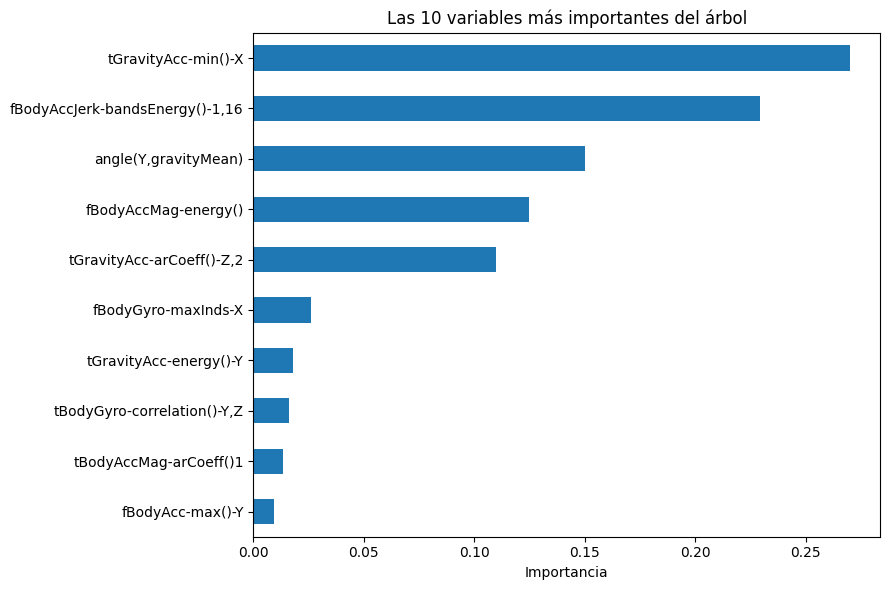

In [ ]:
importancias = pd.Series(
    mejor_arbol.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importancias.head(10).sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Importancia")
plt.title("Las 10 variables más importantes del árbol")
plt.tight_layout()
plt.show()

In [ ]:
print("Profundidad:", mejor_arbol.get_depth())
print("Cantidad de hojas:", mejor_arbol.get_n_leaves())
print("Variables utilizadas:", (importancias > 0).sum())

Profundidad: 7
Cantidad de hojas: 20
Variables utilizadas: 17


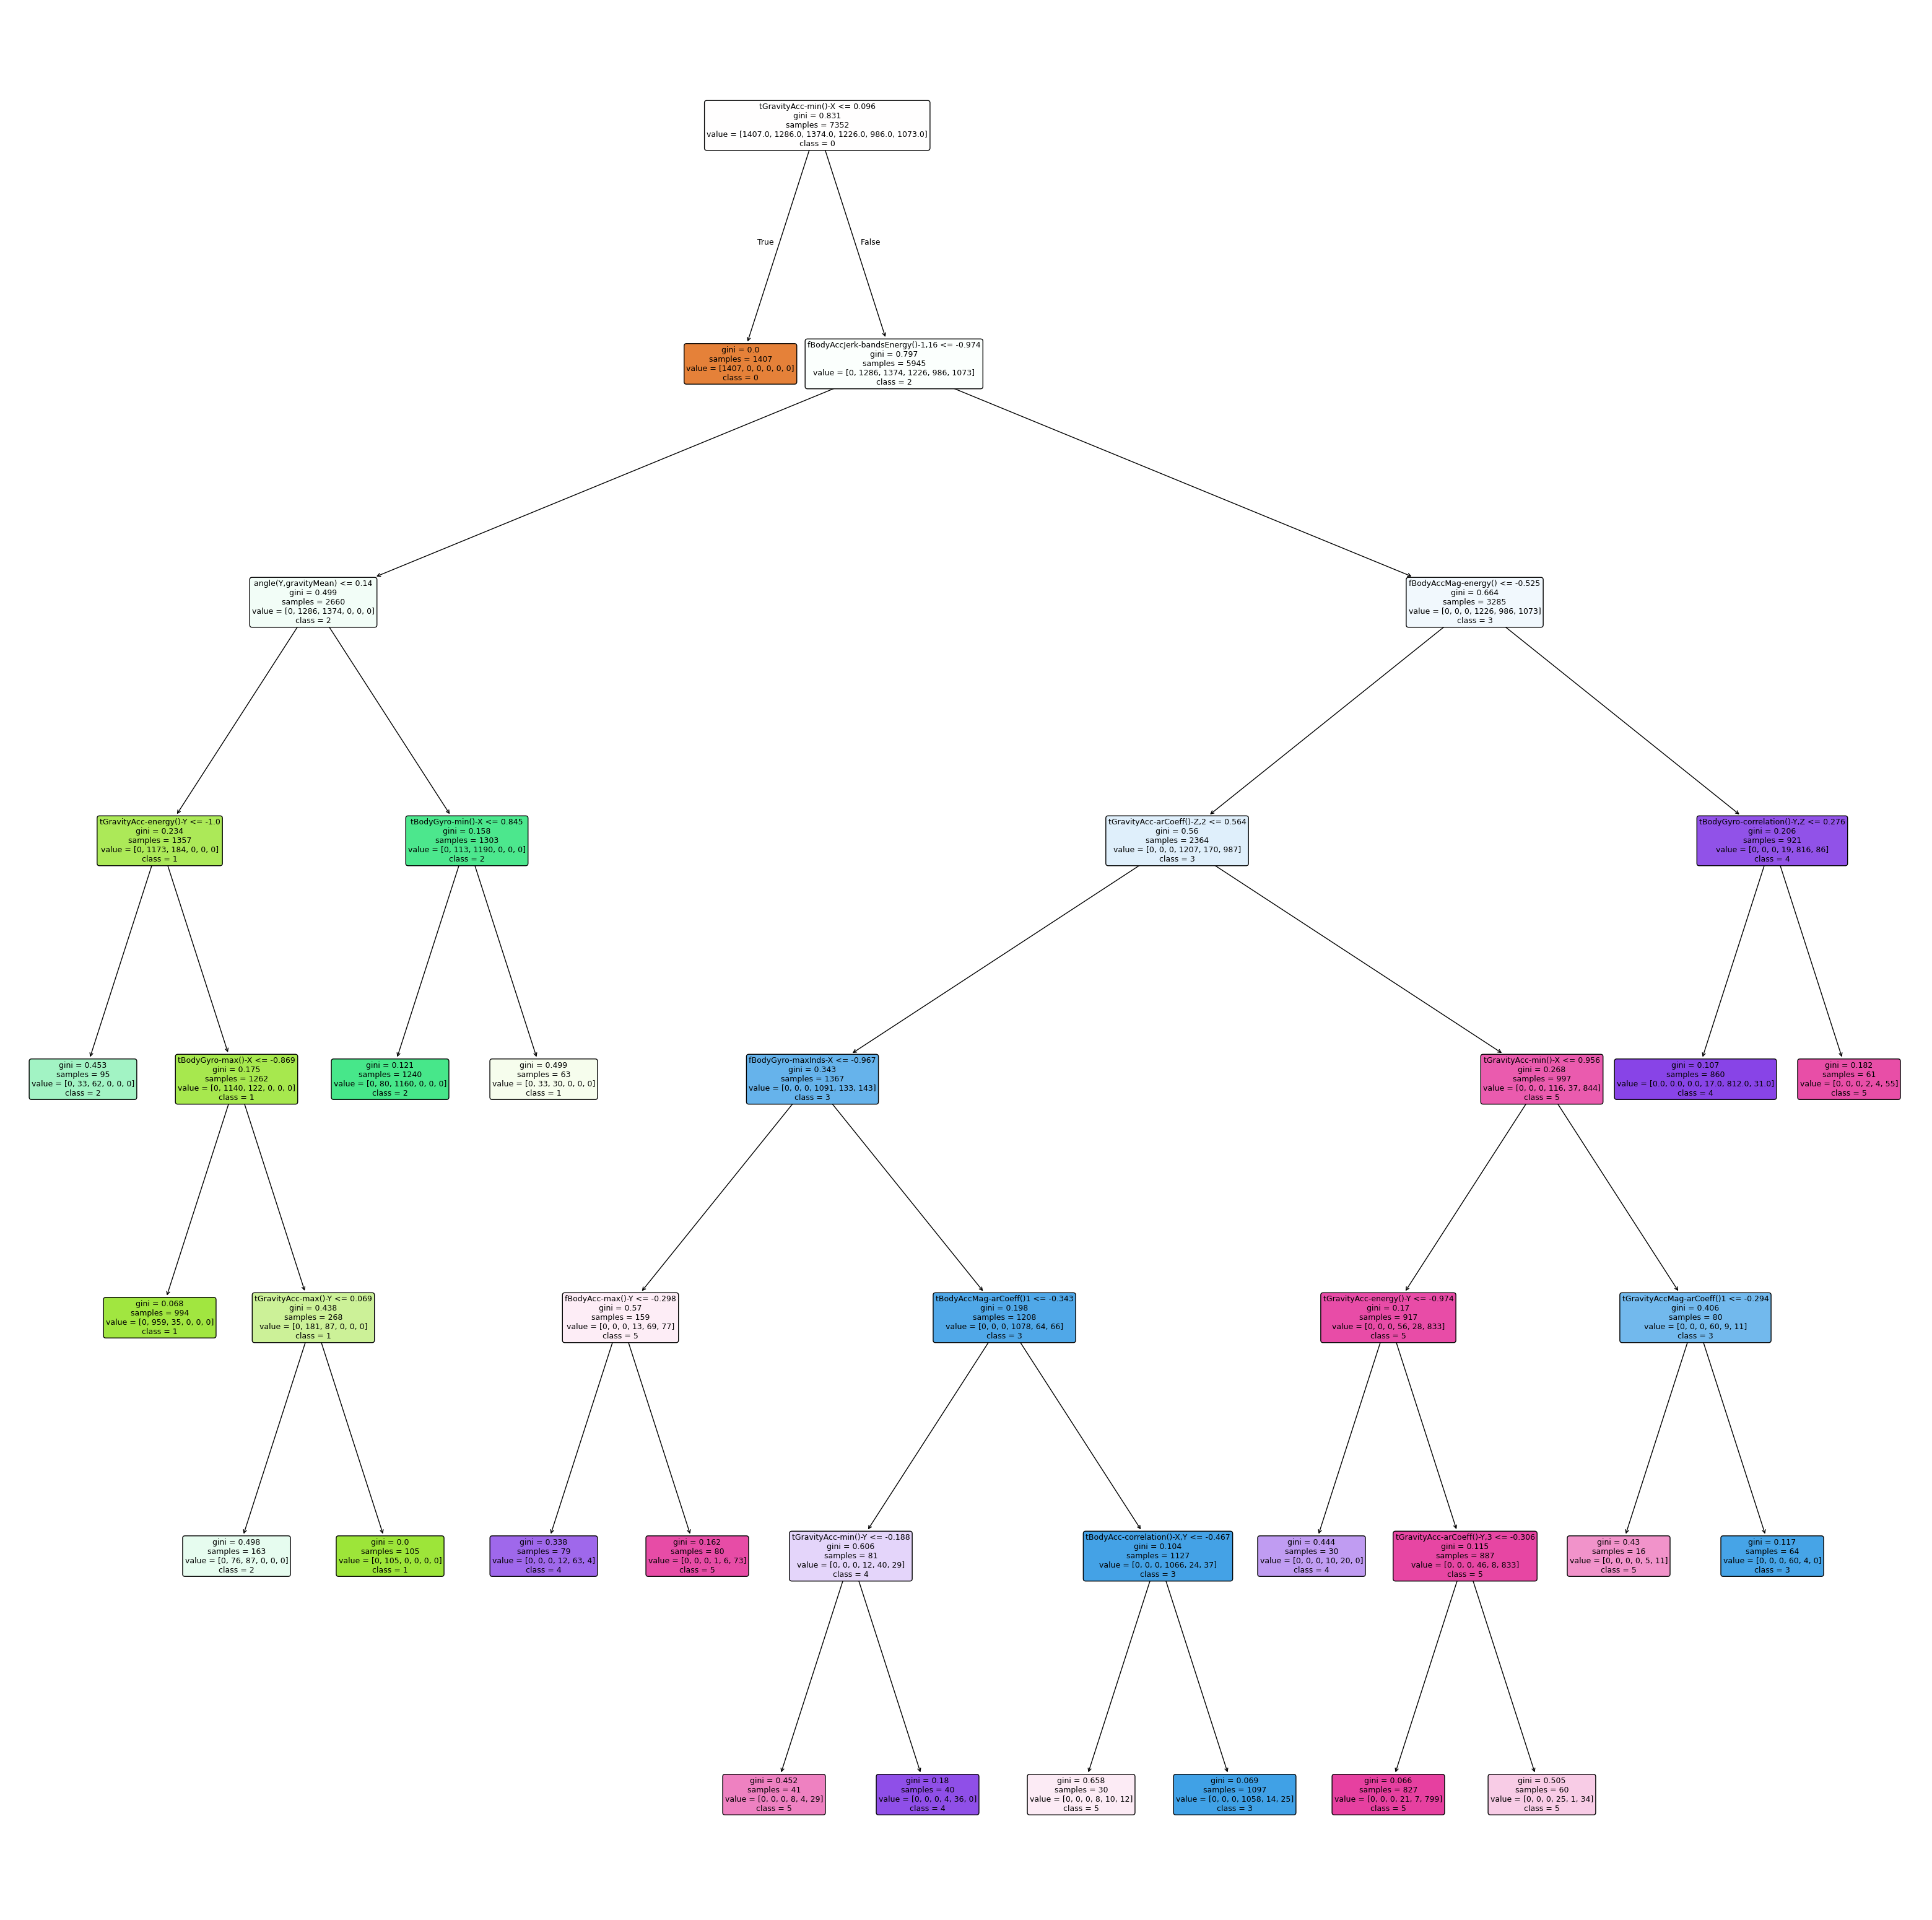

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(40, 40))

plot_tree(
    mejor_arbol,
    feature_names=X_train.columns.tolist(),
    class_names=[str(clase) for clase in mejor_arbol.classes_],
    filled=True,
    rounded=True,
    max_depth=9,
    fontsize=9
)

plt.show()

# FALTA RESPONDER LAS PREGUNTAS Y VER BIEN SI SE TIENE QUE MOSTRAR ESTO ASÍ ASQUEROSO

# 4.3 Modelo 3: Random Forest

Como tercer modelo se utilizará un **Random Forest**, que puede entenderse como un conjunto de muchos árboles de decisión entrenados de manera complementaria.

La idea principal detrás de este método es que, en lugar de confiar en un único árbol, se combinan múltiples árboles para obtener una predicción más robusta.

### Ventajas esperadas

Frente a un árbol individual, un bosque aleatorio suele:

- reducir el sobreajuste,
- mejorar la capacidad de generalización,
- ofrecer mejor desempeño predictivo en muchos problemas reales.

### Aspecto metodológico

Al igual que en el caso anterior, este modelo se entrena sobre las variables originales y no sobre la versión con PCA.  
Esto permite aprovechar la naturaleza del algoritmo y conservar interpretabilidad a través de la importancia de variables.

### Guía Orientadora
- Crear un modelo de Random Forest. Trabajar con los datos sin PCA.
- Hacer un ajuste fino de algunos hiperparámetros.
- Entrenar un modelo optimizado.
- Evaluar la importancia de las variables predictoras.

### Preguntas para pensar

- ¿Por qué un conjunto de árboles puede generalizar mejor que un solo árbol?
- ¿Qué se gana en desempeño y qué se pierde en interpretabilidad?

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

busqueda_rf = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=1,
    ),
    param_distributions={
        "n_estimators": [200],
        "max_depth": [None, 8, 10],
        "min_samples_leaf": [20, 40, 100, 200],
        "max_features": ["sqrt", 0.5, 0.6],
        "class_weight": [None, "balanced"],
    },
    n_iter=40,
    random_state=42,
    cv=GroupKFold(n_splits=5),
    scoring="accuracy",
    n_jobs=5,
    verbose=2,)

busqueda_rf.fit(
    X_train,
    y_train,
    groups=df_train.loc[X_train.index, "subject"],)

mejor_rf = busqueda_rf.best_estimator_

print("Mejores parámetros:", busqueda_rf.best_params_)
print(f"Accuracy promedio en validación: {busqueda_rf.best_score_:.3f}")
print(f"Accuracy en entrenamiento: {mejor_rf.score(X_train, y_train):.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


Hasta este punto se entrenaron tres enfoques distintos:

Regresión Logística,
Árbol de Decisión,
Random Forest.

Ahora que entrenaron y optimizaron los tres modelos, pueden elegir el modelo con el mejor desempeño para evaluarlo finalmente con los datos de test.

El objetivo final no es solo obtener el modelo con el mejor resultado numérico, sino también analizar qué tipo de modelo resulta más adecuado para este problema según distintos criterios.

Preguntas de cierre
1. ¿Qué modelo obtuvo el mejor desempeño con los datos de entrenamiento?
2. ¿Cuál es el desempeño de ese modelo con los datos de test?
3. ¿Qué diferencias observaron entre las matrices de confusión de los distintos modelos?
4. ¿Qué rol jugó PCA en el enfoque lineal?
5. ¿Por qué los modelos basados en árboles se trabajaron sobre las variables originales?
6. Si tuvieran que desplegar uno de estos modelos en una aplicación real, ¿cuál elegirían y por qué?